Step 1 – Load the Merged Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Load merged dataset
df = pd.read_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/processed/task_ai_exposure.csv")

# View first rows
df.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,SOC Code,Occupation Title,AIOE
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334


This helps us understand
number of rows
number of columns
datatype of each column
missing values
basic statistics

In [5]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Information
df.info()

# Summary statistics
df.describe(include='all')

Shape: (15814, 11)
Index(['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type',
       'Incumbents Responding', 'Date', 'Domain Source', 'SOC Code',
       'Occupation Title', 'AIOE'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 15814 entries, 0 to 15813
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   O*NET-SOC Code         15814 non-null  str    
 1   Title                  15814 non-null  str    
 2   Task ID                15814 non-null  int64  
 3   Task                   15814 non-null  str    
 4   Task Type              15560 non-null  str    
 5   Incumbents Responding  15319 non-null  float64
 6   Date                   15814 non-null  str    
 7   Domain Source          15814 non-null  str    
 8   SOC Code               15814 non-null  str    
 9   Occupation Title       15814 non-null  str    
 10  AIOE                   15814 non-null  float64
dtypes: float64(2

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,SOC Code,Occupation Title,AIOE
count,15814,15814,15814.000000,15814,15560,15319.000000,15814,15814,15814,15814,15814.000000
unique,782,782,NaN,14849,2,NaN,23,4,683,683,NaN
top,49-2022.00,Telecommunications Equipment Installers and Re...,NaN,"Maintain student attendance records, grades, a...",Core,NaN,08/2021,Incumbent,17-2199,"Engineers, All Other",NaN
freq,39,39,NaN,34,11657,NaN,1702,11731,179,179,NaN
mean,NaN,NaN,11590.160301,NaN,NaN,63.419414,NaN,NaN,NaN,NaN,0.100558
std,NaN,NaN,6793.693653,NaN,NaN,30.873308,NaN,NaN,NaN,NaN,0.978604
min,NaN,NaN,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,-2.670000
25%,NaN,NaN,5901.250000,NaN,NaN,47.000000,NaN,NaN,NaN,NaN,-0.761000
50%,NaN,NaN,11321.500000,NaN,NaN,63.000000,NaN,NaN,NaN,NaN,0.124000
75%,NaN,NaN,17517.750000,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,1.031000


Before analysis, we need to know which variables contain missing data.

Missing values can occur because

surveys skipped questions
unavailable task ratings
incomplete occupation records

In [6]:

# Missing values
missing = df.isnull().sum()

# Show only columns with missing values
missing = missing[missing > 0]

missing.sort_values(ascending=False)



Incumbents Responding    495
Task Type                254
dtype: int64

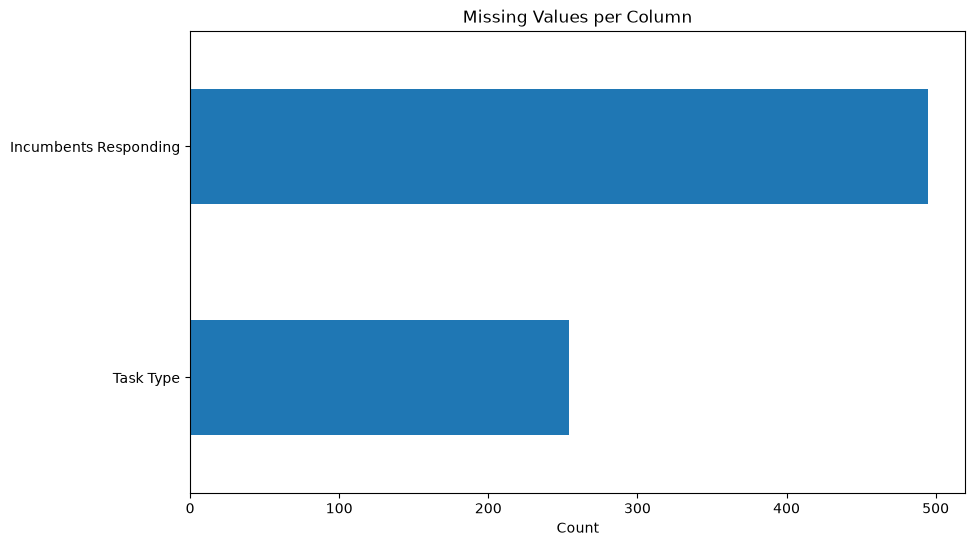

In [7]:
plt.figure(figsize=(10,6))

missing.sort_values().plot(kind='barh')

plt.title("Missing Values per Column")
plt.xlabel("Count")
plt.show()

Duplicate records may bias statistical analysis.

Removing duplicates ensures every occupation-task combination is counted only once.

In [8]:
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (15814, 11)


Machine learning requires correct datatypes.

Examples:

IDs → string
Scores → float
Counts → integer

In [9]:
# Example conversion

df['Task ID'] = df['Task ID'].astype(str)



In [10]:
# Example conversion

df.dtypes

O*NET-SOC Code               str
Title                        str
Task ID                      str
Task                         str
Task Type                    str
Incumbents Responding    float64
Date                         str
Domain Source                str
SOC Code                     str
Occupation Title             str
AIOE                     float64
dtype: object

In [11]:
#Check numerical values
numerical = df.select_dtypes(include=np.number)

numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
Incumbents Responding,15319.0,63.419414,30.873308,18.00,47.000,63.000,81.000,238.000
AIOE,15814.0,0.100558,0.978604,-2.67,-0.761,0.124,1.031,1.528


This plot shows how AI exposure scores are distributed across all tasks.
It helps answer:
Are most tasks highly exposed to AI?
Are exposure scores evenly distributed?
Is the data skewed toward low or high exposure?

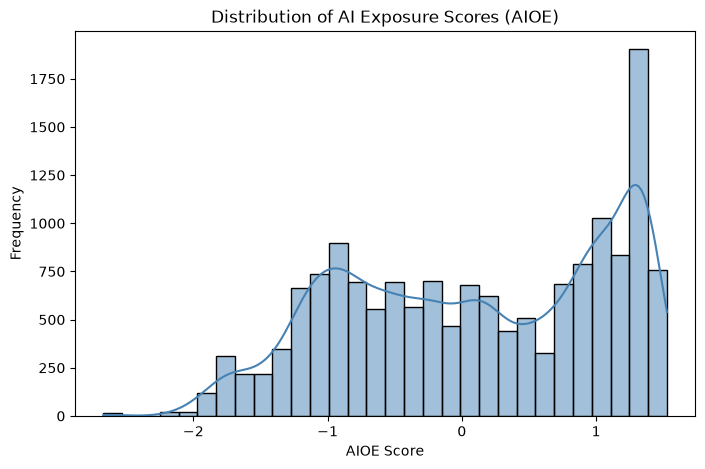

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['AIOE'], bins=30, kde=True, color='steelblue')

plt.title("Distribution of AI Exposure Scores (AIOE)")
plt.xlabel("AIOE Score")
plt.ylabel("Frequency")

plt.show()

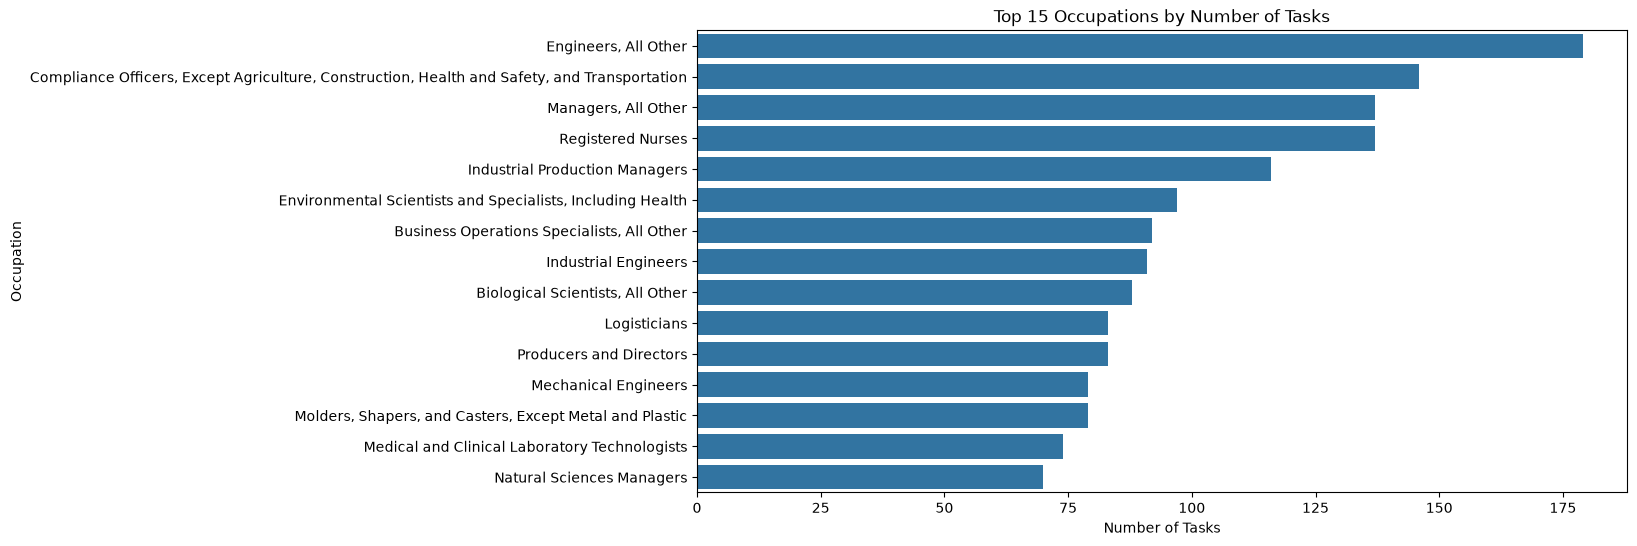

In [13]:
#Top occupation by number of tasks
top_occ = df['Occupation Title'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_occ.values,
    y=top_occ.index
)

plt.title("Top 15 Occupations by Number of Tasks")
plt.xlabel("Number of Tasks")
plt.ylabel("Occupation")

plt.show()

TaskType distribution - This shows how many tasks belong to each task category

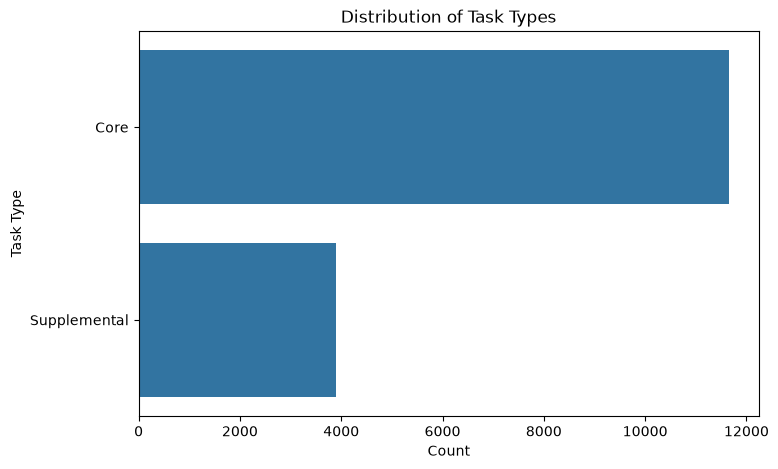

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=df['Task Type'],
    order=df['Task Type'].value_counts().index
)

plt.title("Distribution of Task Types")
plt.xlabel("Count")
plt.ylabel("Task Type")

plt.show()

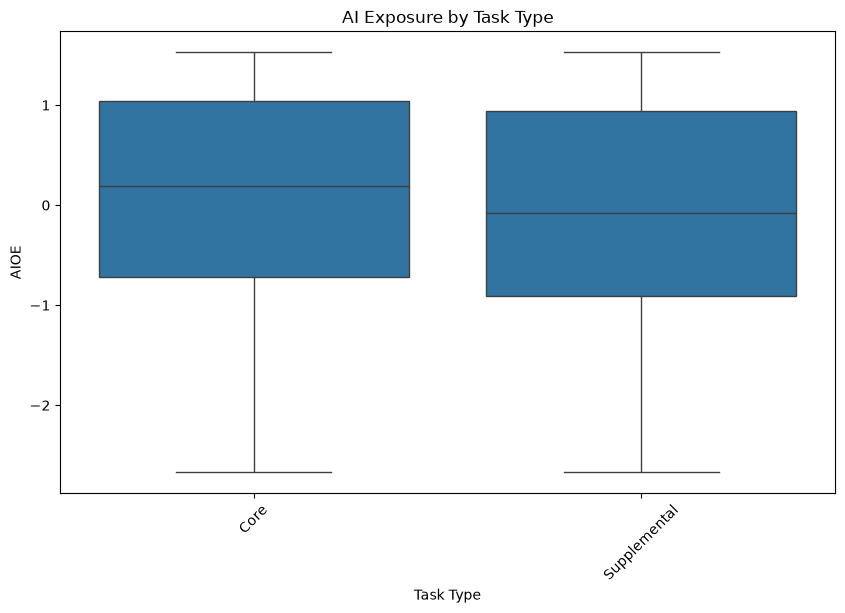

In [15]:
#AI Exposure by Task Type
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Task Type',
    y='AIOE'
)

plt.xticks(rotation=45)

plt.title("AI Exposure by Task Type")

plt.show()

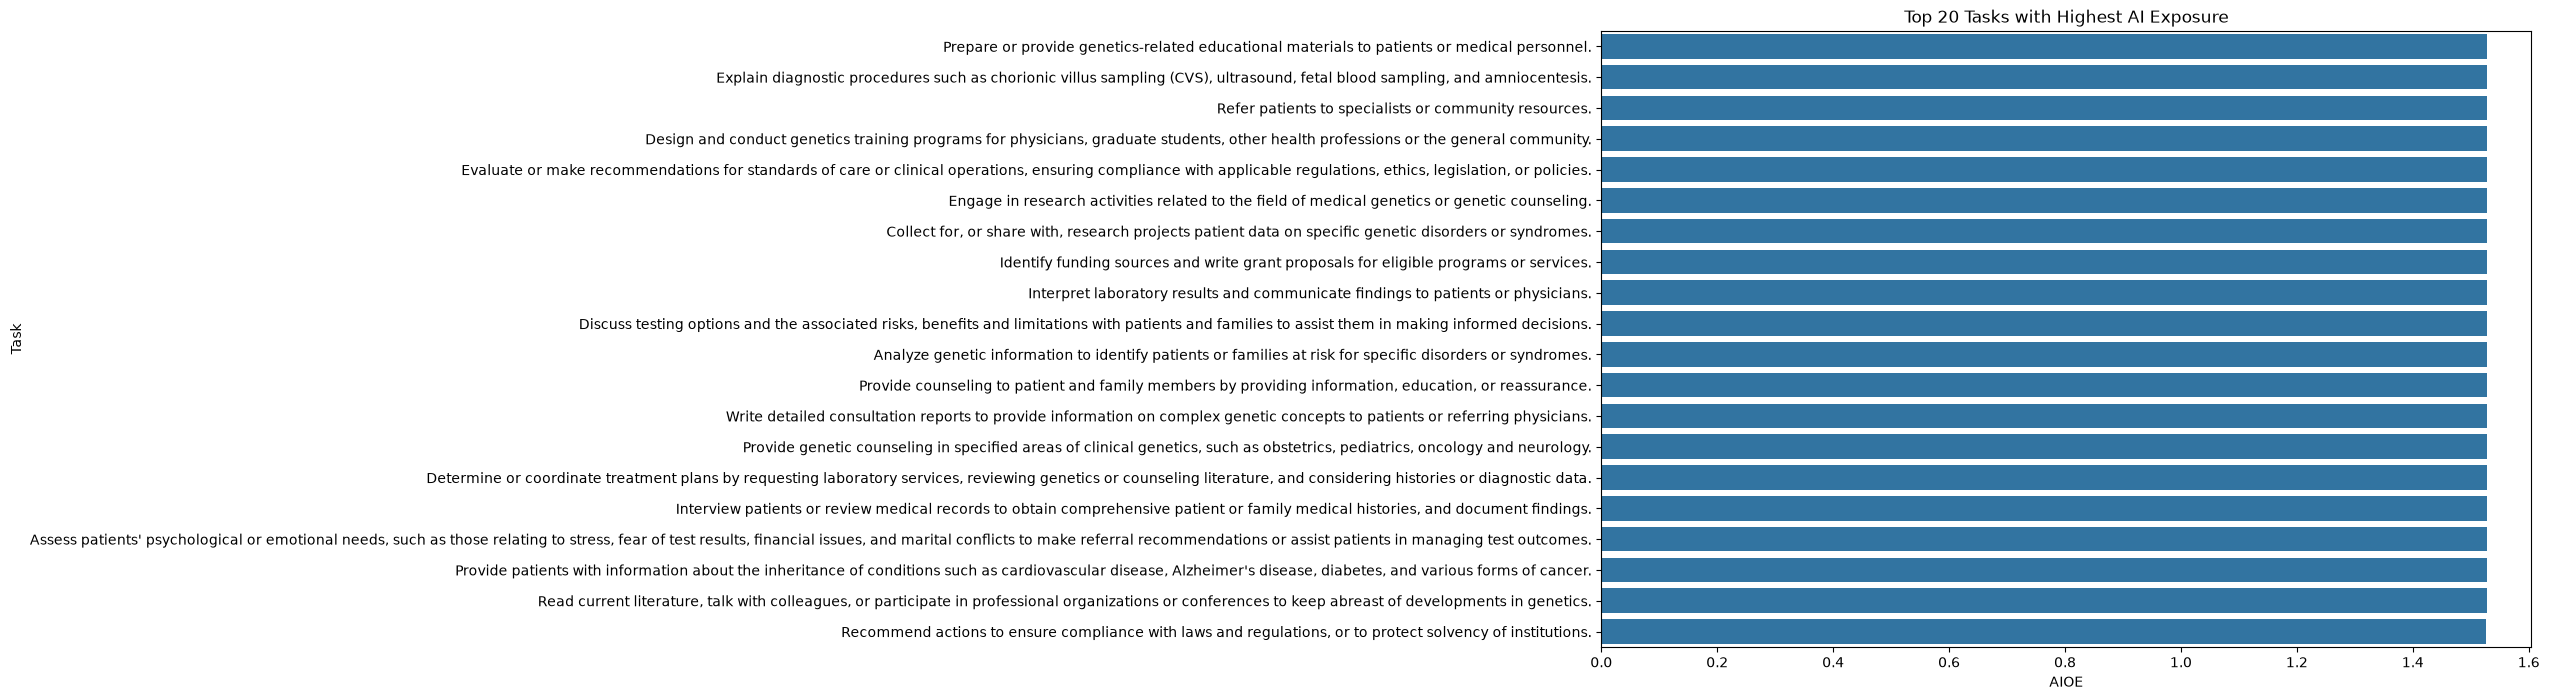

In [16]:
#Top 20 most AI-exposed tasks
top_ai = df.sort_values(by='AIOE', ascending=False).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_ai,
    x='AIOE',
    y='Task'
)

plt.title("Top 20 Tasks with Highest AI Exposure")

plt.show()

In [17]:
#AI-exposure statics
df['AIOE'].describe()

count    15814.000000
mean         0.100558
std          0.978604
min         -2.670000
25%         -0.761000
50%          0.124000
75%          1.031000
max          1.528000
Name: AIOE, dtype: float64

In [18]:
df.to_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/cleaned/cleaned_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
